<a href="https://colab.research.google.com/github/Dijah-Tunrayo/Lab_3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cuda


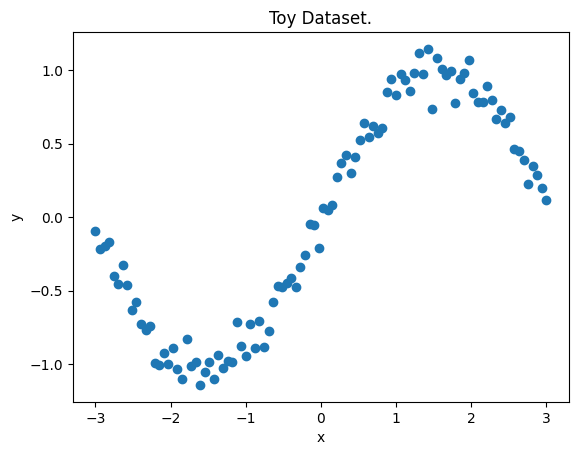

Initial weight: 0.050, Initial bias: -0.014
Step 0, Loss: 0.45172829880627124, w: 0.22679568340090306, b: -0.013138074441576652
Step 20, Loss: 0.1954517987142025, w: 0.33903284271802725, b: -0.010416396541855437
Step 40, Loss: 0.1954517971398298, w: 0.33903284338492196, b: -0.010385017732063413
Step 60, Loss: 0.19545179713962052, w: 0.33903284338492196, b: -0.010384655959017428
Step 80, Loss: 0.1954517971396205, w: 0.33903284338492196, b: -0.010384651788058188
Step 100, Loss: 0.19545179713962046, w: 0.33903284338492196, b: -0.010384651739970309
Step 120, Loss: 0.1954517971396205, w: 0.33903284338492196, b: -0.010384651739415891
Step 140, Loss: 0.1954517971396205, w: 0.33903284338492196, b: -0.010384651739409497
Step 160, Loss: 0.1954517971396205, w: 0.33903284338492196, b: -0.010384651739409442
Step 180, Loss: 0.1954517971396205, w: 0.33903284338492196, b: -0.010384651739409442

Final w: 0.3390, b: -0.0104


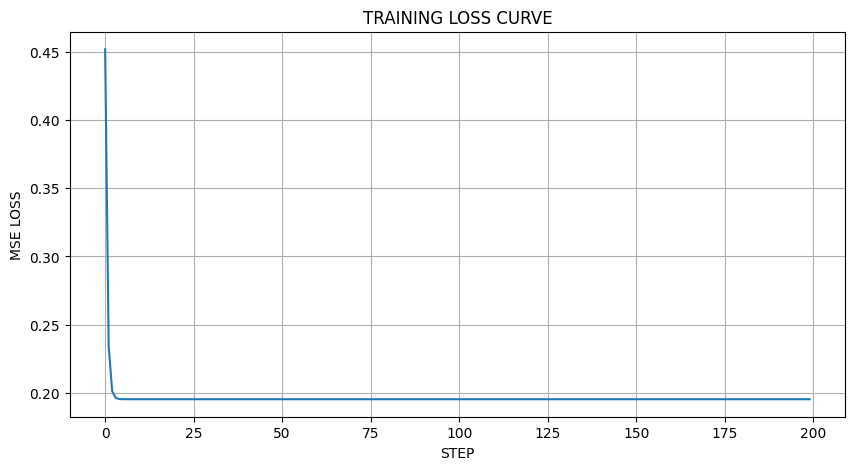

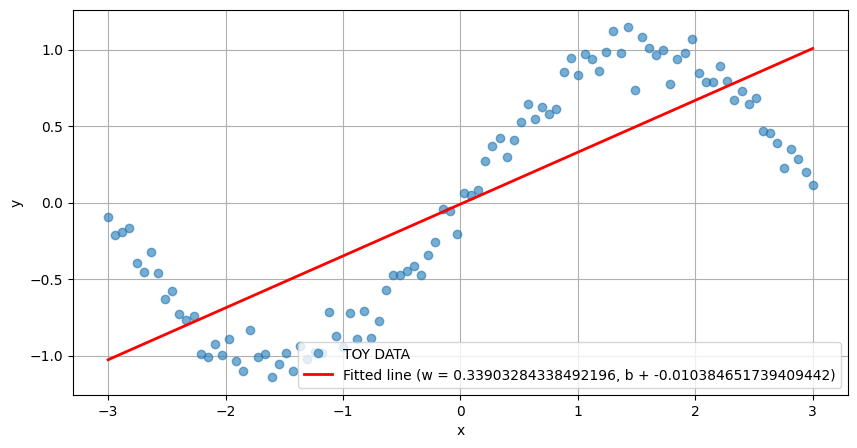

In [43]:

# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

# TODO: Initialise w and b to small random values.

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

#==============================================================================================#
#TODO 1 - Generating toy data and plotting it
np.random.seed(42)

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1,100)
plt.plot(x,y,"o", label = "Noisy Sine Data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Dataset.")
plt.show()


#TODO 2 - Initialising w and b to small random values
np.random.seed(42)
w = np.random.normal(0, 0.1)
b = np.random.normal(0, 0.1)
print(f"Initial weight: {w:.3f}, Initial bias: {b:.3f}")


#TODO 3 - Implementing ONE gradient-descent step by hand?(oh a calculation by hand, sure) and then looping it for ~200 steps
history_loss = [] # A list to store the losses
lr = 0.1

#A for loop for the 200 steps
for i in range(200):
  y_hat = w * x + b
  loss  = np.mean((y_hat - y) ** 2)
  dw    = np.mean(2 * (y_hat - y) * x)
  db    = np.mean(2 * (y_hat - y))
  w    -= lr * dw
  b    -= lr * db
  #Storing the losses
  history_loss.append(loss)

  #This part is to track the progress of the training process
  if i % 20 ==0:
    print(f"Step {i}, Loss: {loss}, w: {w}, b: {b}")

#Final
print(f"\nFinal w: {w:.4f}, b: {b:.4f}")

#TODO 4 - Plotting the loss curve over the 200 steps and the data with the fitted line on top.

#The loss curve
plt.figure(figsize = (10, 5))
plt.plot(history_loss)
plt.xlabel("STEP")
plt.ylabel("MSE LOSS")
plt.title("TRAINING LOSS CURVE")
plt.grid(True)
plt.show()

#plotting the data with a fitted line on top
plt.figure(figsize = (10,5))
plt.plot(x, y, "o", alpha = 0.6, label = "TOY DATA")
plt.plot(x, w * x + b, "r-", linewidth = 2, label = f"Fitted line (w = {w}, b + {b})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

#==============================================================================================#



**STUDENT REASONING**
1.
/insert image here/

2.
This is **UNDERFITTING**.

Reason: A single neuron computes a linear function (provided in code i.e y_hat = w * x + b), which only represent straight lines. A sine wave however, is a nonlinear function and is oscilatory so no matter how long we train, a linear model like above, will never be able to capture the shape of a sine wave. The loss looks plateaued at the top because we have reached the minimum possible error for a linear model, moreover this loss is still too high since the model is too simple to capture the complexity of the data(It has high bias). In order to fix this, we will need to add non-linearities like hidden layers with activation functiions.

INITIALISED PARAMETERS:
W1 shape: (1, 8), b1 shape: (8,)
W2 shape: (8, 1), b2 shape: (1,)
Step    0, Loss: 4.516009
Step  500, Loss: 0.024236
Step 1000, Loss: 0.019667
Step 1500, Loss: 0.016325
Step 2000, Loss: 0.013681
Step 2500, Loss: 0.011954

Final loss with tanh: 0.010999


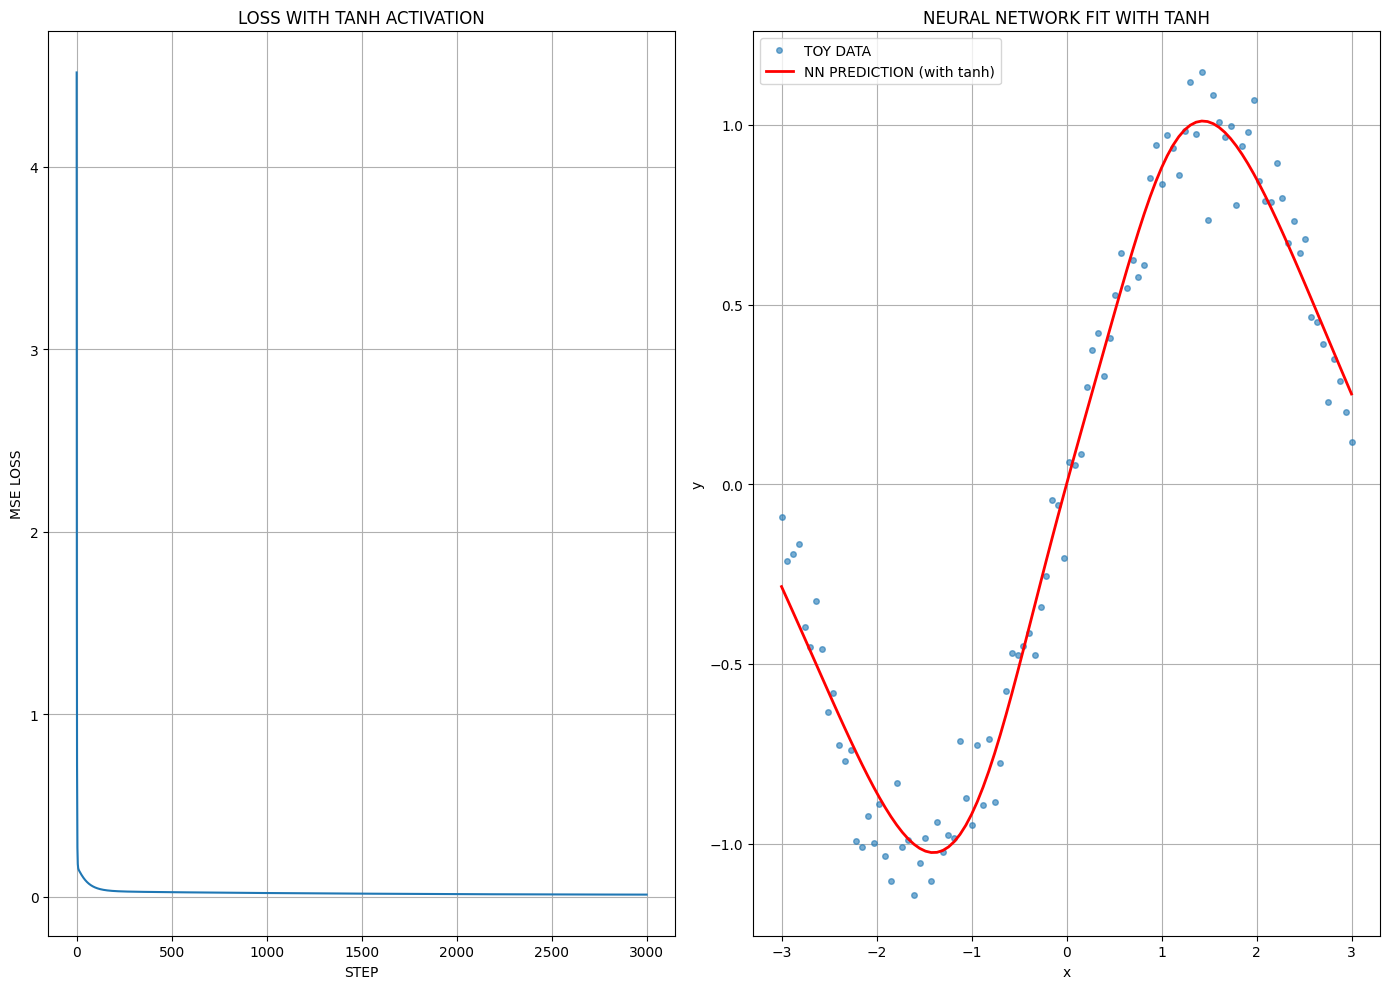

Step    0, Loss: 7.185317
Step  500, Loss: 0.195452
Step 1000, Loss: 0.195452
Step 1500, Loss: 0.195452
Step 2000, Loss: 0.195452
Step 2500, Loss: 0.195452

Final loss without tanh: 0.195452


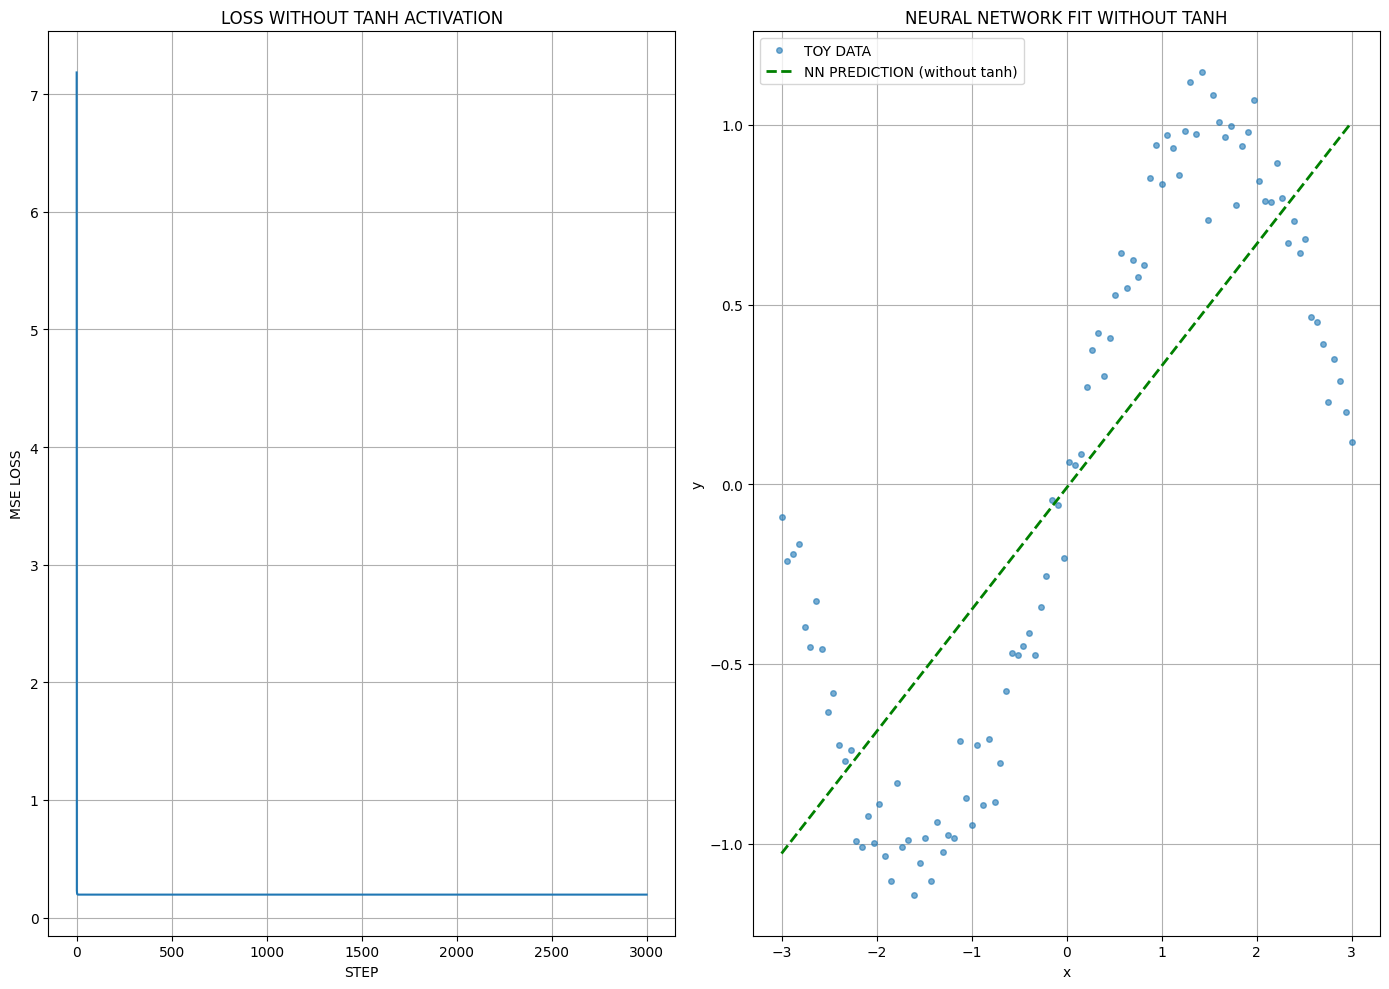


COMPARISON: With Tanh vs Without Tanh


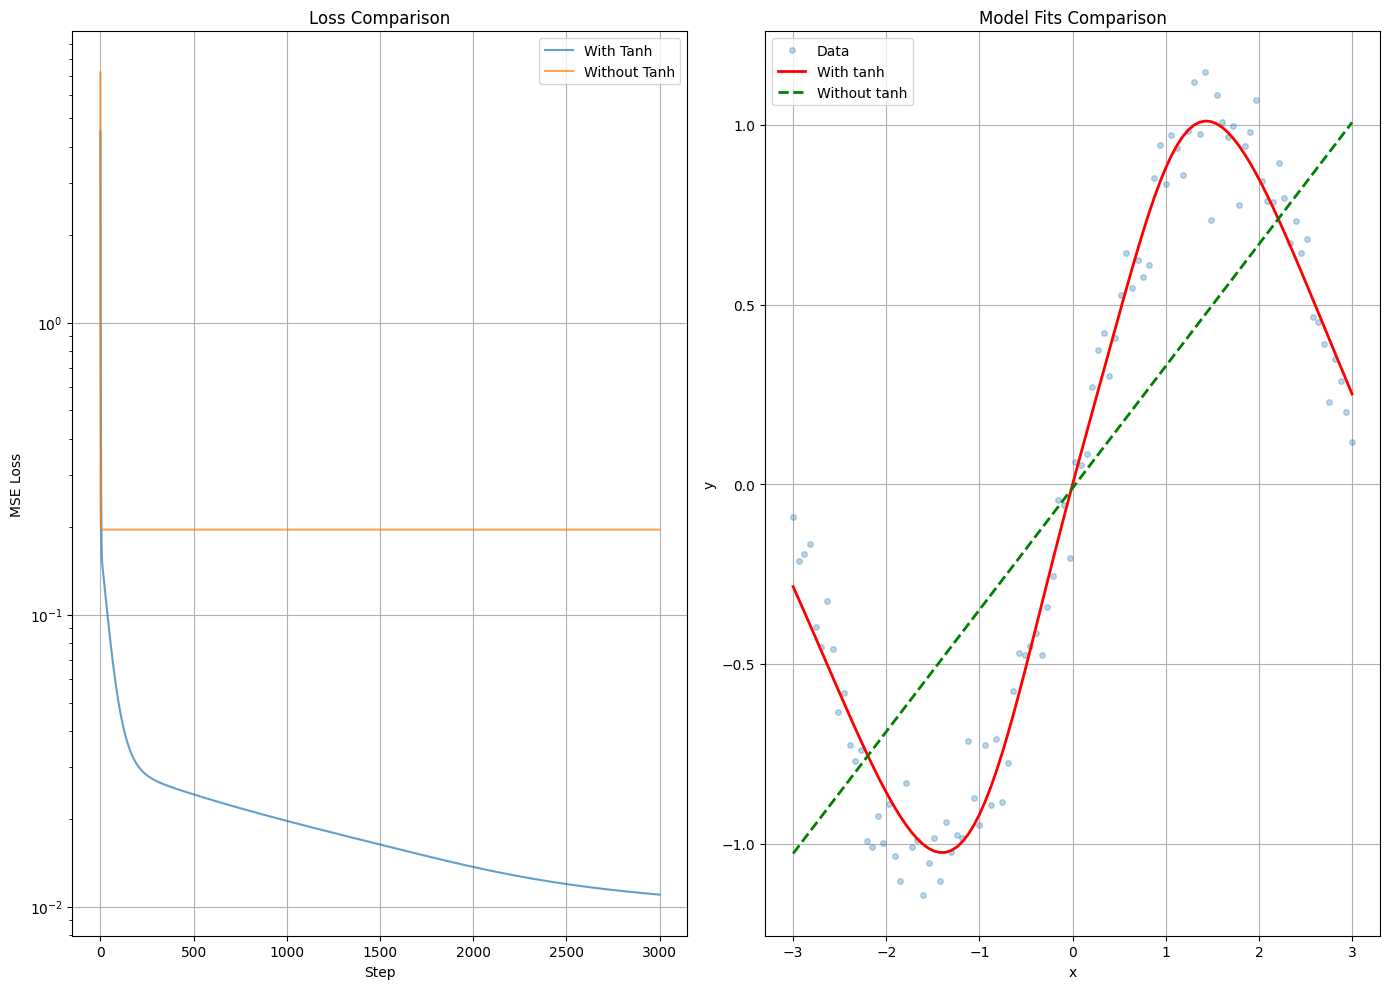

In [44]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

#==============================================================================================#
#TODO 1 - Initialising parameters
np.random.seed(42)

W1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5

print("INITIALISED PARAMETERS:")
print(f"W1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}, b2 shape: {b2.shape}")


#Before the forward pass, we train the loop with tanh activation
lr = 0.05
n_steps = 3000
tanh_loss_history = []

for step in range(n_steps):
  #TODO 2 - Forward Pass
  z1 = x.reshape(-1,1) @ W1 + b1  #pre-activation
  h = np.tanh(z1)                 #activation
  y_hat = h @ W2 + b2             #output

  #Loss
  loss = np.mean((y_hat.reshape(-1) - y) ** 2)
  tanh_loss_history.append(loss)


  #TODO 3 - Backward Pass
  d_yhat = 2 * (y_hat.reshape(-1) - y) / len(y)
  d_yhat = d_yhat.reshape(-1,1)

  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis = 0)

  dh = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)

  dW1 = x.reshape(-1,1).T @ dz1
  db1 = dz1.sum(axis=0)

  #TODO 4 - Updating all the parameters with learning rate and looping for ~3000 steps
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

  if step % 500 == 0:
    print(f"Step {step:4d}, Loss: {loss:.6f}")

print(f"\nFinal loss with tanh: {tanh_loss_history[-1]:.6f}")


#TODO 5 - Plotting the loss curve and final fit over the data
#Plotting the results
plt.figure(figsize = (14, 10))

#Loss curves
plt.subplot(1, 2, 1)
plt.plot(tanh_loss_history)
plt.xlabel("STEP")
plt.ylabel("MSE LOSS")
plt.title("LOSS WITH TANH ACTIVATION")
plt.grid(True)

#Final fit
plt.subplot(1, 2, 2)
plt.plot(x, y, "o", alpha = 0.6, label = "TOY DATA", markersize = 4)
plt.plot(x, y_hat.reshape(-1), 'r-', linewidth=2, label='NN PREDICTION (with tanh)')
plt.xlabel('x')
plt.ylabel('y')
plt.title("NEURAL NETWORK FIT WITH TANH")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



#==============================================================================================#


# Re-Running without tanh (h = z1)
np.random.seed(42)
W1_no = np.random.randn(1,8) * 0.5
b1_no = np.random.randn(8) * 0.5
W2_no = np.random.randn(8,1) * 0.5
b2_no = np.random.randn(1) * 0.5

lr_no = 0.05
n_steps_no = 3000
no_tanh_loss_history = []


for step in range(n_steps_no):
  #Forward pass Without tanh
  z1_no = x.reshape(-1,1) @ W1_no + b1_no
  h_no = z1_no  # NO ACTIVATION
  y_hat_no = h_no @ W2_no + b2_no

  #Loss
  loss_no = np.mean((y_hat_no.reshape(-1) - y) ** 2)
  no_tanh_loss_history.append(loss_no)

  #Backward pass
  d_yhat_no = 2 * (y_hat_no.reshape(-1) - y) / len(y)
  d_yhat_no = d_yhat_no.reshape(-1,1)

  dW2_no = h_no.T @ d_yhat_no
  db2_no = d_yhat_no.sum(axis=0)

  dh_no = d_yhat_no @ W2_no.T
  dz1_no = dh_no  # derivative of identity = 1

  dW1_no = x.reshape(-1,1).T @ dz1_no
  db1_no = dz1_no.sum(axis=0)

  # Update
  W1_no -= lr_no * dW1_no
  b1_no -= lr_no * db1_no
  W2_no -= lr_no * dW2_no
  b2_no -= lr_no * db2_no

  if step % 500 == 0:
      print(f"Step {step:4d}, Loss: {loss_no:.6f}")

print(f"\nFinal loss without tanh: {no_tanh_loss_history[-1]:.6f}")

plt.figure(figsize = (14,10))

#Loss curves
plt.subplot(1, 2, 1)
plt.plot(no_tanh_loss_history)
plt.xlabel("STEP")
plt.ylabel("MSE LOSS")
plt.title("LOSS WITHOUT TANH ACTIVATION")
plt.grid(True)

#Final fit
plt.subplot(1, 2, 2)
plt.plot(x, y, "o", alpha = 0.6, label = "TOY DATA", markersize = 4)
plt.plot(x, y_hat_no.reshape(-1), 'g--', linewidth=2, label='NN PREDICTION (without tanh)')
plt.xlabel('x')
plt.ylabel('y')
plt.title("NEURAL NETWORK FIT WITHOUT TANH")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#==============================================================================================#
print("\n" + "="*60)
print("COMPARISON: With Tanh vs Without Tanh")
print("="*60)

# Plot comparison
plt.figure(figsize=(14, 10))

#Loss comparison
plt.subplot(1, 2, 1)
plt.plot(tanh_loss_history, label='With Tanh', alpha=0.7)
plt.plot(no_tanh_loss_history, label='Without Tanh', alpha=0.7)
plt.xlabel('Step')
plt.ylabel('MSE Loss')
plt.title('Loss Comparison')
plt.legend()
plt.grid(True)
plt.yscale('log')

#Fit comparison
plt.subplot(1, 2, 2)
plt.plot(x, y, 'o', alpha=0.3, label='Data', markersize=4)
plt.plot(x, y_hat.reshape(-1), 'r-', linewidth=2, label='With tanh')
plt.plot(x, y_hat_no.reshape(-1), 'g--', linewidth=2, label='Without tanh')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Model Fits Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#==============================================================================================#


**STUDENT REASONING**

1.


With tanh removed, the network becomes a composition of linear transformations. For a 2-layer network:
$h = x * W1 + b1$

$\hat{y}= h * W2 + b2$.

Substituting h into the second equation, it then becomes:

$\hat{y} = (x · W1 + b1) · W2 + b2$

$\hat{y} = x · (W1 · W2) + (b1 · W2 + b2)%$

This makes it mathematically equivalent to a single neuron with

$W(eff) = W1 · W2  (effective weight)$

$b(eff) = b1 · W2 + b2  (effective bias)$

Since the composition of linear functions is always linear, no matter how many linear layers you stack, the entire network will be linear. This is mainly why it cannot fot the non-linear sine function.


2.

The hidden layer's 8 neurons served as adaptive bias functions that the network combines to approximate the target function.

Each neuron does the following:

a. Applies the non-linear tanh activation function to transform the nput using its own weight and bias into different s-shaped curved functions at specific locations and steepness.


3.

Back propagation is an algorithm that efficiently computes the gradient of the loss with respect to every parameter(weight and bias) set in the network by applying backwards, the chain rule from output to input, moving layer by layer.


LEARNING RATE COMPARISON

Training with learning rate: 0.001
  Final loss: 0.071819
  Best loss:  0.071819 at step 2999

Training with learning rate: 0.05
  Final loss: 0.010999
  Best loss:  0.010999 at step 2999

Training with learning rate: 1.0
  Final loss: nan
  Best loss:  4.516009 at step 0


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_752/4188662114.py:37: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat.reshape(-1) - y) ** 2)
/tmp/ipykernel_752/4188662114.py:47: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_752/4188662114.py:50: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)  # derivative of tanh


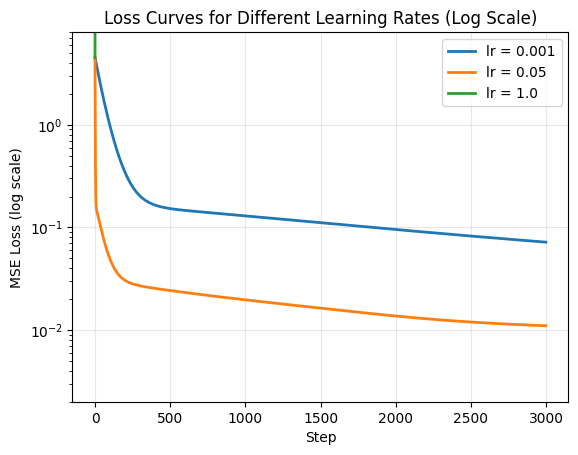

In [45]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

#==============================================================================================#

#TODO 1 - Wrapping part 1.2 in the function, train_toy which returns the list of losses

def train_toy(lr, steps=3000, use_tanh=True):

  #Resetting the parameters with the same seed for fair comparison
  np.random.seed(42)
  W1 = np.random.randn(1,8) * 0.5
  b1 = np.random.randn(8) * 0.5
  W2 = np.random.randn(8,1) * 0.5
  b2 = np.random.randn(1) * 0.5



  loss_history = []


  for step in range(steps):
    # Forward pass
    z1 = x.reshape(-1,1) @ W1 + b1
    if use_tanh:
        h = np.tanh(z1)  # With tanh
    else:
        h = z1  # Without tanh (linear)
    y_hat = h @ W2 + b2

    # Loss
    loss = np.mean((y_hat.reshape(-1) - y) ** 2)
    loss_history.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat.reshape(-1) - y) / len(y)
    d_yhat = d_yhat.reshape(-1,1)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    if use_tanh:
        dz1 = dh * (1 - np.tanh(z1) ** 2)  # derivative of tanh
    else:
        dz1 = dh  # derivative of identity = 1

    dW1 = x.reshape(-1,1).T @ dz1
    db1 = dz1.sum(axis=0)

    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

  # Store final predictions
  final_y_hat = y_hat.reshape(-1).copy()

  return loss_history, final_y_hat

#TODO 2 - Running it with THREE learning rates while keeping the same initial weights for fair comparison

# Test Learning rates

learning_rates = [0.001, 0.05, 1.0]
loss_histories = {}
final_predictions = {}

print("LEARNING RATE COMPARISON")

for lr in learning_rates:
  print(f"\nTraining with learning rate: {lr}")
  loss_history, final_y_hat = train_toy(lr=lr, steps=3000, use_tanh=True)
  loss_histories[lr] = loss_history
  final_predictions[lr] = final_y_hat
  print(f"  Final loss: {loss_history[-1]:.6f}")
  print(f"  Best loss:  {min(loss_history):.6f} at step {loss_history.index(min(loss_history))}")


#TODO 3 - Plotting the 3 loss curves on the same axes

# Plot - Loss Curves (using log scale for better visibility of the differences )
for lr in learning_rates:
    plt.plot(loss_histories[lr], label=f'lr = {lr}', linewidth=2)
plt.ylim(2e-3, 8)
plt.xlabel('Step')
plt.ylabel('MSE Loss (log scale)')
plt.title('Loss Curves for Different Learning Rates (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

#==============================================================================================#

1. **LEARNING RATE = 0.001 (TOO COLD)**

The loss decreases at the slowest rate here, and plateaus at a relatively high value. The model never reaches the optimal minimum (3000 steps) because it takes too tiny steps.


2.  **LEARNING RATE = 0.5 (JUST RIGHT)**

The loss decreases smoothly ans consistently here without any instability. Its large enough to make meaningful progress quickly but also samll enough to avoid overshooting the minimum.


3. **LEARNING RATE = 1.0 (TOO HOT)**

The loss here oscilated wildly since the size of the step is massive, sometimes reaching very large values. This occurs because the gradient descent step is too large causing an overshot and back and forth movement instead of converging.


**WHY A LARGE LEARNING RATE DOESNT LEARN FASTER**
When a learning rate is too big, the optimiser jumps over the minimum and lands on the other side of the slop often times with a higher loss, also if the jump is large enough it may cause model explosion and since the optimiser keeps jumping back and forth across the minimum without settleing, it leads to unstable training of the model

In [47]:

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
#==============================================================================================#
#IMPORTS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
#==============================================================================================#
# TODO 1 - Loading the Obesity Dataset from Lab 2

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)



# TODO 2 - Encoding the categoricals as done in lab 2

#Checking the existence of the target to be sure
"NObeyesdad" in obesity.columns
#Separating the x and y before encoding to avoid a key error again(it happened)
x = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

#Encoding the features only
binary_cols = ["family_history_with_overweight",
               "FAVC",
               "SMOKE",
               "SCC"
              ]
for col in binary_cols:
    x[col] = x[col].map({"yes": 1, "no": 0})

#Then the categorical data (OneHotEncoder)
x = pd.get_dummies(x, drop_first=True)

# TODO 3 - Stratified train / validation / test split (60/20/20)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Training set, validation set,Test set all split, using stratify
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y
)

x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)





# TODO 4 - Fitting a StandardScaler on the TRAINING set only; transform all three splits.
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)


# TODO 5 - Convert to tensors and wrap in DataLoaders:

X_train_tensor = torch.tensor(x_train, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.long)

X_val_tensor = torch.tensor(x_val, dtype = torch.float32)
y_val_tensor = torch.tensor(y_val, dtype = torch.long)

X_test_tensor = torch.tensor(x_test, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

# Creating the Tensor Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Creating the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#==============================================================================================#


**STUDENT REASONING**
1.
CrossEntropyLoss in pytorch expects integer class labels because its designedto be much more efficient and numerically stable. It uses nn.LogSoftmax and nn.NLLLoss together to pick the correct logit for efficient loss calculation.

2.
Neural Networks care about feature scaling because they utilise gradient descent to optimise their weights and gradient descent is sensitive to the scale of input features.

3.
Shuffle = True, randomly permutes the order of training samples before each epoch(step), which prevents the model fro learning the order or pattern of the data and aids it in learning better and more efficiently.